상황 1: 데이터셋 로딩 중...
상황 2: Scikit-Learn 전처리 파이프라인 아키텍처 설계 중...

=== [실험 1] 일반 선형 회귀(OLS) 구동 ===
Linear Regression -> Train RMSE: $17,813.35 | Val RMSE: $22,277.04
🚨 진단: 원-핫 인코딩으로 인한 차원 폭발로 치명적인 '과대적합(Overfitting)' 발생 확인.

=== [실험 2] GridSearchCV 기반 하이퍼파라미터 튜닝 ===
사지방 백엔드 가상 서버에서 5-Fold 교차 검증 연산 중...
🥇 최적의 하이퍼파라미터 검증 완료: alpha = 0.001
Optimized Lasso -> Train RMSE: $26,430.27 | Val RMSE: $25,105.84

상황 3: 시각화 차트 생성 및 저장 중...
💡 분석 리포트: 총 287개 특성 중 오직 82개만 살아남고 나머지는 0으로 제거됨.
🎯 이미지 파일 'lasso_top_features.png' 저장 완료! (블로그 첨부용)


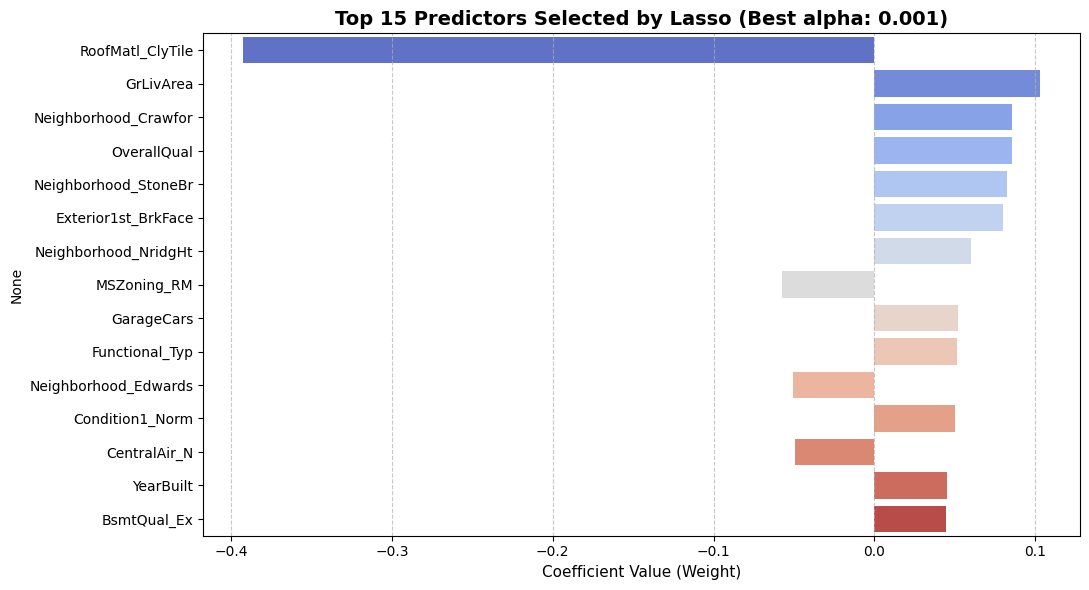

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error

# ==========================================
# 1. 데이터 로드 및 타겟 변수 전처리
# ==========================================
url = 'https://raw.githubusercontent.com/coders1019/AI-Study-From-Scratch/main/01_ML_Core_Theory/01_Preprocessing_Linear_Regression/train.csv'
print("상황 1: 데이터셋 로딩 중...")
train_df = pd.read_csv(url)

# 데이터 분리 (ID와 타겟인 SalePrice 제외)
X = train_df.drop(['Id', 'SalePrice'], axis=1)
y = train_df['SalePrice']

# 타겟 변수(주택가격)의 왜도(Skewness) 완화를 위한 로그 변환
y_log = np.log1p(y)

# 데이터 스누핑 원천 차단: 전처리 수행 전 train/val 순수 데이터 격리
X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

# ==========================================
# 2. 강력한 전처리 파이프라인 구축
# ==========================================
print("상황 2: Scikit-Learn 전처리 파이프라인 아키텍처 설계 중...")

# 수치형 변수와 범주형 변수 자동으로 분류
num_attribs = X.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = X.select_dtypes(include=['object']).columns.tolist()

# 멀티모달 분포 변수 처리 (예: 'GarageArea' 변수 지정)
multimodal_feature = 'GarageArea'
if multimodal_feature in num_attribs:
    num_attribs.remove(multimodal_feature)

# 멀티모달 전용 버킷타이징(K-Means) 파이프라인 구축
multimodal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('bucketizer', KBinsDiscretizer(n_bins=3, encode='onehot-dense', strategy='kmeans'))
])

# 수치형 변수 파이프라인: 결측치 중앙값 대체 + 표준화 스케일링
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 범주형 변수 파이프라인: 결측치 최빈값 대체 + 원-핫 인코딩
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 결합: ColumnTransformer를 통해 모든 전처리 아키텍처 통합
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
    ('multimodal', multimodal_pipeline, [multimodal_feature])
])

# 메가 파이프라인(Mega Pipeline) 구축: 전처리 프로세서와 학습 모델 결합
mega_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=20000))
])

# ==========================================
# 3. 기준 모델(Baseline) 평가 - 일반 선형 회귀
# ==========================================
print("\n=== [실험 1] 일반 선형 회귀(OLS) 구동 ===")
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

lin_train_rmse = root_mean_squared_error(np.expm1(y_train), np.expm1(lin_reg.predict(X_train_processed)))
lin_val_rmse = root_mean_squared_error(np.expm1(y_val), np.expm1(lin_reg.predict(X_val_processed)))
print(f"Linear Regression -> Train RMSE: ${lin_train_rmse:,.2f} | Val RMSE: ${lin_val_rmse:,.2f}")
print("🚨 진단: 원-핫 인코딩으로 인한 차원 폭발로 치명적인 '과대적합(Overfitting)' 발생 확인.")

# ==========================================
# 4. 하이퍼파라미터 최적화 - GridSearchCV 도입
# ==========================================
print("\n=== [실험 2] GridSearchCV 기반 하이퍼파라미터 튜닝 ===")

# 파이프라인 구조에 맞춰 파라미터 그리드 키 값 설정
param_grid = {'model__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 1.0, 10.0, 100.0]}

# 5-Fold 교차 검증을 메가 파이프라인 전체에 적용
lasso_grid = GridSearchCV(mega_pipeline, param_grid, cv=5,
                          scoring='neg_root_mean_squared_error',
                          return_train_score=True)

print("사지방 백엔드 가상 서버에서 5-Fold 교차 검증 연산 중...")
# 순수한 X_train과 y_train만 주입하여 교차 검증 내 데이터 누수 완전히 차단
lasso_grid.fit(X_train, y_train)

# 최적의 결과 도출
best_alpha = lasso_grid.best_params_['model__alpha']
best_mega_model = lasso_grid.best_estimator_
print(f"🥇 최적의 하이퍼파라미터 검증 완료: alpha = {best_alpha}")

# 최적 메가 모델로 최종 성능 계산 (로그 스케일 복원 원칙 적용)
lasso_train_rmse = root_mean_squared_error(np.expm1(y_train), np.expm1(best_mega_model.predict(X_train)))
lasso_val_rmse = root_mean_squared_error(np.expm1(y_val), np.expm1(best_mega_model.predict(X_val)))
print(f"Optimized Lasso -> Train RMSE: ${lasso_train_rmse:,.2f} | Val RMSE: ${lasso_val_rmse:,.2f}")

# ==========================================
# 5. Lasso 특성 선택 시각화
# ==========================================
print("\n상황 3: 시각화 차트 생성 및 저장 중...")

# 파이프라인 내부 구조에서 인코더 변수명 추출
cat_encoder = best_mega_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
encoded_cat_features = cat_encoder.get_feature_names_out(cat_attribs).tolist()

multi_encoder = best_mega_model.named_steps['preprocessor'].named_transformers_['multimodal'].named_steps['bucketizer']
encoded_multi_features = multi_encoder.get_feature_names_out([multimodal_feature]).tolist()

# 전체 피처 리스트 결합
all_features = num_attribs + encoded_cat_features + encoded_multi_features

# 특성 중요도(가중치 계수) 매핑
lasso_coefs = pd.Series(best_mega_model.named_steps['model'].coef_, index=all_features)
active_coefs = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print(f"💡 분석 리포트: 총 {len(all_features)}개 특성 중 오직 {len(active_coefs)}개만 살아남고 나머지는 0으로 제거됨.")

# 상위 15개 핵심 특성 그래프 그리기
plt.figure(figsize=(11, 6))
sns.barplot(x=active_coefs.head(15).values, y=active_coefs.head(15).index, hue=active_coefs.head(15).index, palette='coolwarm', legend=False)
plt.title(f"Top 15 Predictors Selected by Lasso (Best alpha: {best_alpha})", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Value (Weight)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('lasso_top_features.png', dpi=150)
print("🎯 이미지 파일 'lasso_top_features.png' 저장 완료! (블로그 첨부용)")
plt.show()